# Airfoil Self-Noise

NASA data set, obtained from a series of aerodynamic and acoustic tests of two and three-dimensional airfoil blade sections conducted in an anechoic wind tunnel.

Brooks, T., Pope, D., & Marcolini, M. (1989). Airfoil Self-Noise [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5VW2C.

In [4]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import sklearn as sk
import pandas as pd
import seaborn as sns
import numpy as np
import scipy as stats

In [5]:
  
# fetch dataset 
dataset = fetch_ucirepo(id=291) 
  
# data (as pandas dataframes) 
X = dataset.data.features 
y = dataset.data.targets 

In [6]:
# variable information 
print(dataset.variables) 

                                  name     role        type demographic  \
0                            frequency  Feature     Integer        None   
1                         attack-angle  Feature      Binary        None   
2                         chord-length  Feature  Continuous        None   
3                 free-stream-velocity  Feature  Continuous        None   
4  suction-side-displacement-thickness  Feature  Continuous        None   
5                scaled-sound-pressure   Target  Continuous        None   

  description units missing_values  
0        None    Hz             no  
1        None   deg             no  
2        None     m             no  
3        None   m/s             no  
4        None     m             no  
5        None    dB             no  


In [7]:
# first 5 rows of the dataset
print(X.head())

# simple statistics of the dataset
print(X.describe())

   frequency  attack-angle  chord-length  free-stream-velocity  \
0        800           0.0        0.3048                  71.3   
1       1000           0.0        0.3048                  71.3   
2       1250           0.0        0.3048                  71.3   
3       1600           0.0        0.3048                  71.3   
4       2000           0.0        0.3048                  71.3   

   suction-side-displacement-thickness  
0                             0.002663  
1                             0.002663  
2                             0.002663  
3                             0.002663  
4                             0.002663  
          frequency  attack-angle  chord-length  free-stream-velocity  \
count   1503.000000   1503.000000   1503.000000           1503.000000   
mean    2886.380572      6.782302      0.136548             50.860745   
std     3152.573137      5.918128      0.093541             15.572784   
min      200.000000      0.000000      0.025400             31.70

# Visual and dataframe exploration

In [8]:
def plot_histograms(X):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
    axes = axes.flatten()

    for i, feature in enumerate(X.columns):
        axes[i].hist(X[feature], bins=30, alpha=0.7)
        axes[i].set_title(f'Histogram of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(axis='y', alpha=0.75)

    for j in range(len(X.columns), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

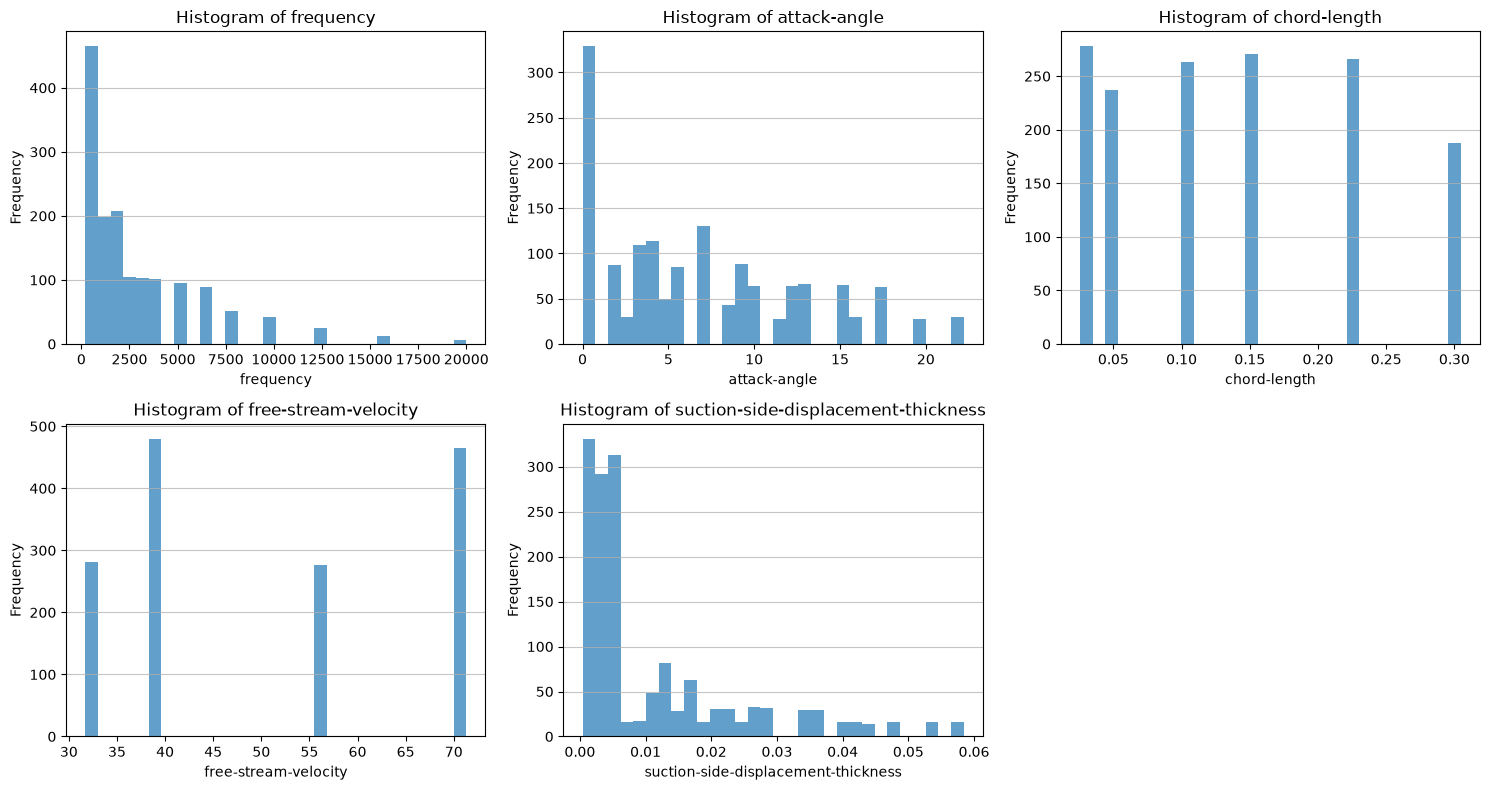

In [9]:
# Pre-cleaning histograms
plot_histograms(X)

In [10]:
# Add normalization to the features to avoid frequency bias (tens of thousands of Hz vs. tens of deg)
X = pd.DataFrame(
    sk.preprocessing.normalize(pd.DataFrame(X, columns=dataset.data.features.columns), axis=0, norm='l2'),
    columns=dataset.data.features.columns
)

         frequency  attack-angle  chord-length  free-stream-velocity  \
count  1503.000000   1503.000000   1503.000000           1503.000000   
mean      0.017421      0.019438      0.021282              0.024665   
std       0.019028      0.016961      0.014579              0.007552   
min       0.001207      0.000000      0.003959              0.015373   
25%       0.004829      0.005732      0.007918              0.019204   
50%       0.009657      0.015476      0.015835              0.019204   
75%       0.024143      0.028373      0.035629              0.034576   
max       0.120715      0.063625      0.047505              0.034576   

       suction-side-displacement-thickness  
count                          1503.000000  
mean                              0.016676  
std                               0.019685  
min                               0.000600  
25%                               0.003795  
50%                               0.007421  
75%                               0.

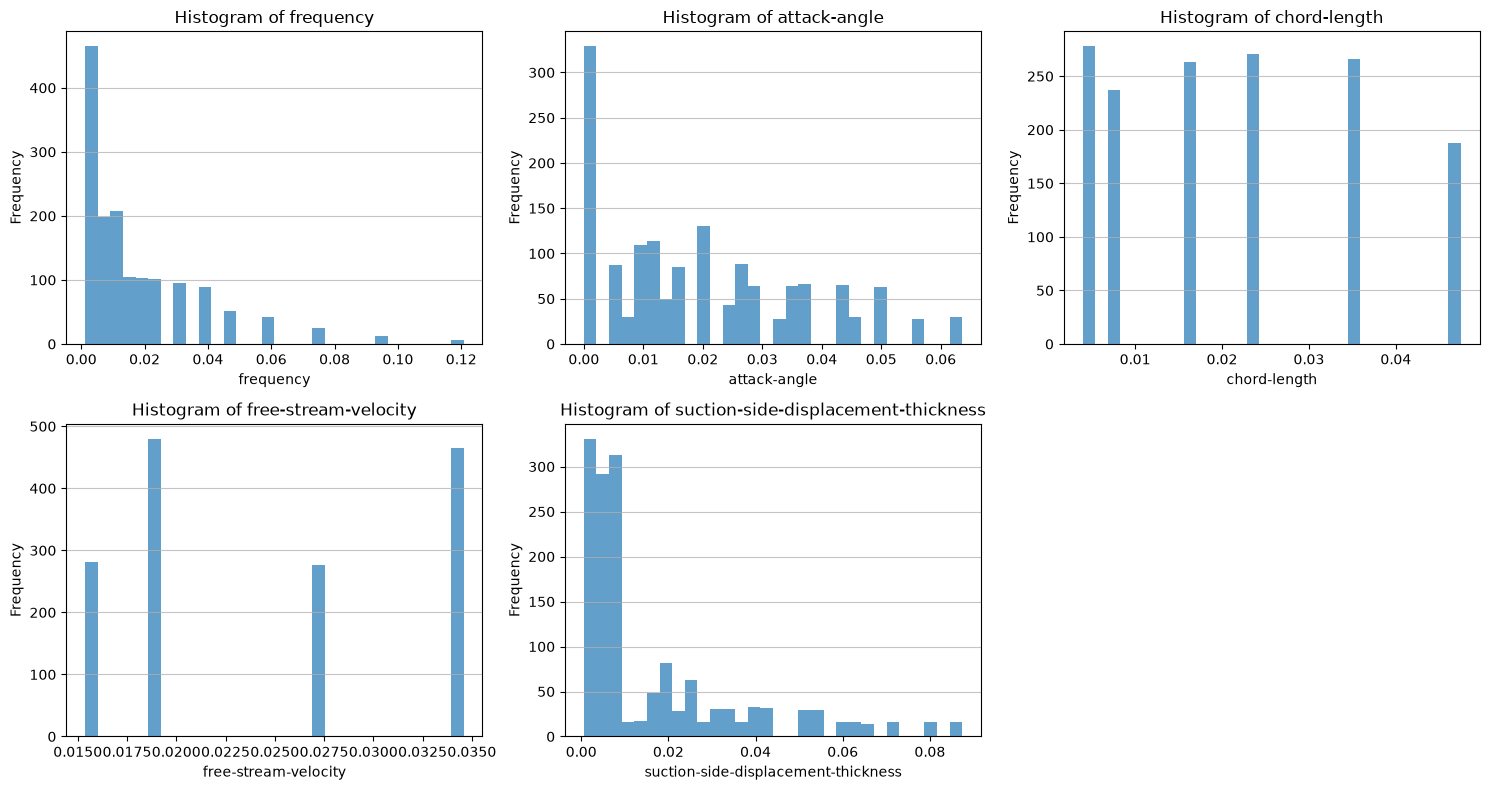

In [11]:
# Check new statistics after normalization and plot histograms again
print(X.describe())
plot_histograms(X)

# Train simple regresion model and check for feature characteristics

Feature: 0, Score: 31.39469
Feature: 1, Score: 7.06075
Feature: 2, Score: 32.77274
Feature: 3, Score: 8.82140
Feature: 4, Score: 72.71233


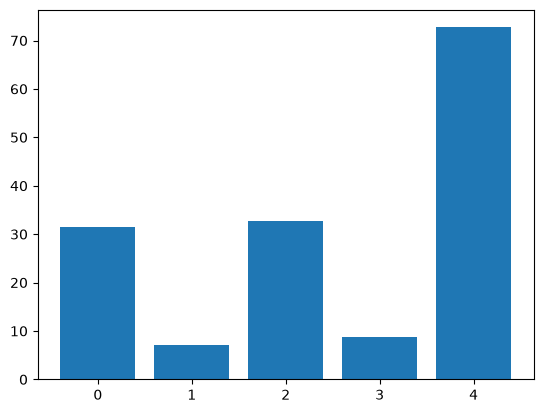

In [12]:
# linear regression feature importance
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot
# define dataset
X_train, y_train = make_regression(n_samples=1000, n_features=5, n_informative=5, random_state=1)
# define the model
model = LinearRegression()
# fit the model
model.fit(X_train, y_train)
# get importance
importance = model.coef_
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

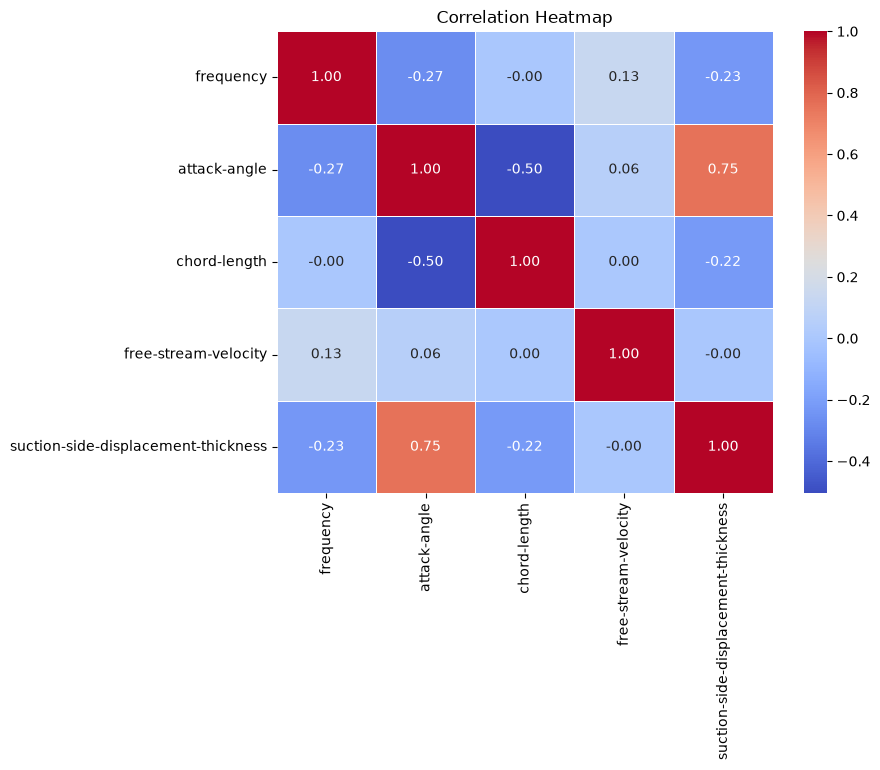

In [13]:
matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

There's a 0.75 correlation between *attack-angle* and *suction-side-displacement-thickness*, but i think we can leave since the rest of the matrix is negative correlated.

# Statistic Analysis

In [14]:
target = y.squeeze()

print(f"\nSkewness: {target.skew():.3f}")
print(f"Kurtosis: {target.kurt():.3f}")

# Outliers via IQR
Q1, Q3 = target.quantile(0.25), target.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = target[(target < lower) | (target > upper)]

total_count = len(target)
outlier_count = len(outliers)
print(f"\nOutliers (IQR method): {outlier_count} de {total_count} ({100*outlier_count/total_count:.1f}%)")


Skewness: -0.419
Kurtosis: -0.314

Outliers (IQR method): 4 de 1503 (0.3%)


We need to adapt the target, we'll try log and sqrt to get a skewness = 0

In [15]:
from scipy import stats

y_loh = np.log1p(target)  # Apply log transformation to the target variable
y_sqrt = np.sqrt(target)  # Apply square root transformation to the target variable
y_box_cox, _ = stats.boxcox(target + 1)  # Apply Box-Cox transformation to the target variable

# Check skewness and kurtosis after transformations
print(f"\nSkewness after log transformation: {y_loh.skew():.3f}")
print(f"Kurtosis after log transformation: {y_loh.kurt():.3f}")
print(f"\nSkewness after square root transformation: {y_sqrt.skew():.3f}")
print(f"Kurtosis after square root transformation: {y_sqrt.kurt():.3f}")
print(f"\nSkewness after Box-Cox transformation: {pd.Series(y_box_cox).skew():.3f}")
print(f"Kurtosis after Box-Cox transformation: {pd.Series(y_box_cox).kurt():.3f}")


Skewness after log transformation: -0.547
Kurtosis after log transformation: -0.140

Skewness after square root transformation: -0.483
Kurtosis after square root transformation: -0.233

Skewness after Box-Cox transformation: -0.044
Kurtosis after Box-Cox transformation: -0.540


We'll check some training with no transformation, log, box-cox, etc. 

# Group division to avoid data leakage

In [22]:
from sklearn.model_selection import GroupShuffleSplit
df = X.copy()
df['scaled-sound-pressure'] = y.values

# Definir el grupo: todo lo que identifica el mismo perfil/experimento físico
group_cols = ["attack-angle", "chord-length", "free-stream-velocity"]
df["group_id"] = df[group_cols].astype(str).agg("-".join, axis=1)

print(f"Número de grupos únicos: {df['group_id'].nunique()}")
print(f"Filas totales: {len(df)}")
print(f"Filas promedio por grupo: {len(df) / df['group_id'].nunique():.1f}")

# Split por grupo, no por fila
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["group_id"]))

train_df = df.iloc[train_idx].drop(columns="group_id")
test_df = df.iloc[test_idx].drop(columns="group_id")

# Verificación: ningún grupo debe aparecer en ambos splits
train_groups = set(df.iloc[train_idx]["group_id"])
test_groups = set(df.iloc[test_idx]["group_id"])
assert len(train_groups & test_groups) == 0, "¡Leakage detectado!"

print(f"\nTrain: {len(train_df)} filas, Test: {len(test_df)} filas")
print("Split limpio, sin overlap de grupos.")

Número de grupos únicos: 106
Filas totales: 1503
Filas promedio por grupo: 14.2

Train: 1182 filas, Test: 321 filas
Split limpio, sin overlap de grupos.


# Symbolic Regression training using PySR

In [25]:
from pysr import PySRRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import os

# Create output directories if they don't exist
os.makedirs("results", exist_ok=True)

TARGET = "scaled_sound_pressure"
FEATURES = ["frequency", "attack_angle", "chord_length",
            "free_stream_velocity", "suction_side_displacement_thickness"]

# Rename columns to replace hyphens with underscores (PySR requirement)
train_df_renamed = train_df.copy()
test_df_renamed = test_df.copy()

rename_dict = {col: col.replace("-", "_") for col in train_df.columns}
train_df_renamed = train_df_renamed.rename(columns=rename_dict)
test_df_renamed = test_df_renamed.rename(columns=rename_dict)

# Use the train/test split created earlier (no data leakage)
X_train, y_train = train_df_renamed[FEATURES].values, train_df_renamed[TARGET].values
X_test, y_test = test_df_renamed[FEATURES].values, test_df_renamed[TARGET].values

model = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log", "sqrt", "square", "exp"],
    populations=20,
    maxsize=40,                 # límite de complejidad de la ecuación
    model_selection="best",     # mejor balance accuracy/simplicidad
    loss="loss(x, y) = (x - y)^2",
    random_state=42,
    procs=4,                    # ajusta a tus cores disponibles
    verbosity=1,
)

model.fit(X_train, y_train, variable_names=FEATURES)

print("\n=== Mejores ecuaciones encontradas ===")
print(model.equations_[["complexity", "loss", "equation"]])

print("\n=== Ecuación seleccionada ===")
print(model.sympy())

# Evaluación en test
y_pred = model.predict(X_test)
print(f"\nR² test: {r2_score(y_test, y_pred):.4f}")
print(f"MAE test: {mean_absolute_error(y_test, y_pred):.4f}")

model.equations_.to_csv("results/equations.csv", index=False)
with open("results/best_equation.txt", "w") as f:
    f.write(str(model.sympy()))

f:\repos\SymbolicRegressionAirfoil\.venv\Lib\site-packages\pysr\sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
f:\repos\SymbolicRegressionAirfoil\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
f:\repos\SymbolicRegressionAirfoil\.venv\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.670e+05
Progress: 859 / 20000 total iterations (4.295%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.773e+01  0.000e+00  y = 124.92
3           4.762e+01  1.120e-03  y = 124.94 - frequency
4           4.030e+01  1.671e-01  y = 127.16 / exp(frequency)
6           3.255e+01  1.068e-01  y = 129.26 / exp(frequency + suction_side_displacement_thi...
                                      ckness)
7           3.182e+01  2.274e-02  y = 95.636 / (frequency + (suction_side_displacement_thick...
                                      ness + 0.73208))
8           2.762e+01  1.415e-01  y = 131.95 / exp(chord_length + (suction_side_displacement...
                                      _thickness + frequency))
10          2.581e+01  3.392e-02  y = (185.16 /

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.773e+01  0.000e+00  y = 124.92
3           4.762e+01  1.120e-03  y = 124.94 - frequency
4           4.030e+01  1.671e-01  y = 127.16 / exp(frequency)
5           4.009e+01  5.248e-03  y = 105.48 / (frequency + 0.82693)
6           3.255e+01  2.083e-01  y = 129.26 / exp(frequency + suction_side_displacement_thi...
                                      ckness)
7           3.164e+01  2.835e-02  y = ((suction_side_displacement_thickness + frequency) * -...
                                      160.3) + 130.42
8           2.762e+01  1.359e-01  y = 131.95 / exp(suction_side_displacement_thickness + (ch...
                                      ord_length + frequency))
9           2.564e+01  7.430e-02  y = (((suction_side_displacement_thickness + frequency) + ...
                                      chord_length) * -174) + 134.46
10      